# Citi Bike Station Demand - Exploratory Data Analysis

In [1]:
import sys
from pathlib import Path
# Determine project root: if cwd is notebooks/, go up one level
project_root = Path.cwd().resolve()
if not (project_root / "src").exists() and (project_root / ".." / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import preprocess
from simulate_docks import simulate_inventory, label_risk
from config import DATA_PROCESSED

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Data Loading and Overview

In [2]:
hourly, station_info = preprocess()
print(f"Stations: {station_info.shape[0]}")
print(f"Hourly records: {hourly.shape[0]}")
print(f"Date range: {hourly['hour'].min()} to {hourly['hour'].max()}")
hourly.head()

Loading raw data...


Cleaning...


Filtering stations...


Aggregating to hourly...


Saved 56168 hourly records for 30 stations.
Stations: 30
Hourly records: 56168
Date range: 2025-12-31 10:00:00 to 2026-03-31 23:00:00


,station_id,hour,departures,latitude,longitude,arrivals,net_flow
0,5276.04,2026-01-01 00:00:00,0,0.0,0.0,3,3
1,5276.04,2026-01-01 01:00:00,4,0.0,0.0,1,-3
2,5276.04,2026-01-01 02:00:00,4,0.0,0.0,1,-3
3,5276.04,2026-01-01 03:00:00,3,0.0,0.0,2,-1
4,5276.04,2026-01-01 04:00:00,1,0.0,0.0,0,-1


In [3]:
hourly.describe()

,hour,departures,latitude,longitude,arrivals,net_flow
count,56168,56168.000000,56168.000000,56168.000000,56168.000000,56168.000000
mean,2026-02-15 16:30:06.537530,8.663331,35.538477,-64.537784,8.605362,-0.057969
min,2025-12-31 10:00:00,0.000000,0.000000,-74.008210,0.000000,-133.000000
25%,2026-01-22 18:00:00,2.000000,40.730207,-73.995299,2.000000,-2.000000
50%,2026-02-15 22:00:00,6.000000,40.742869,-73.990741,6.000000,0.000000
75%,2026-03-10 23:00:00,12.000000,40.751873,-73.981693,12.000000,2.000000
max,2026-03-31 23:00:00,175.000000,40.766953,0.000000,120.000000,85.000000
std,NaN,9.237260,13.601333,24.699978,9.120927,6.471002


## 2. Temporal Demand Patterns

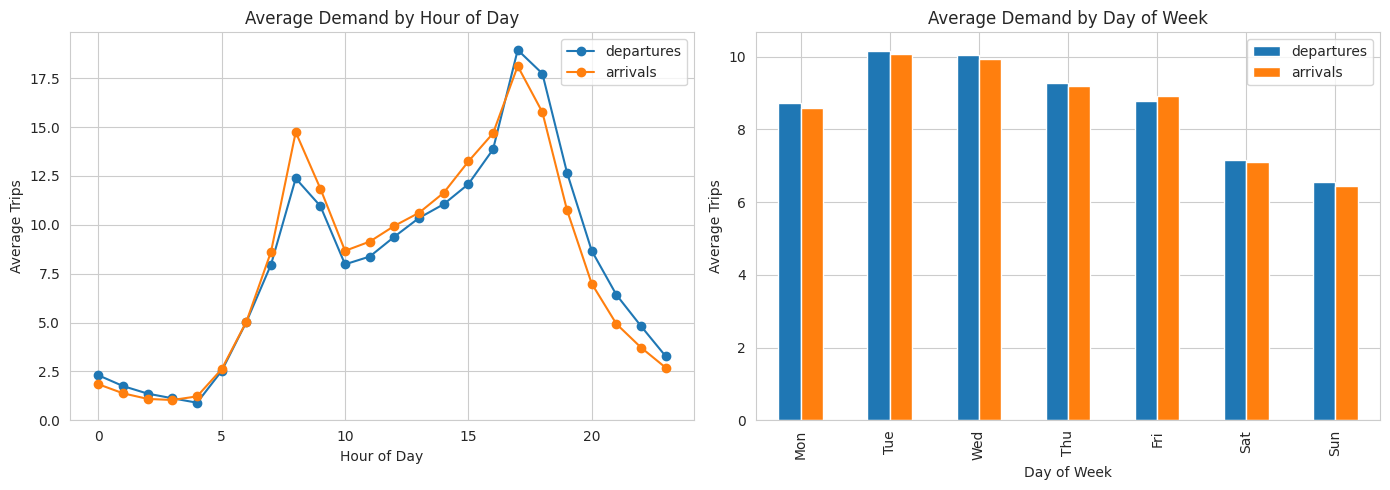

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_hour = hourly.groupby(hourly["hour"].dt.hour)[["departures", "arrivals"]].mean()
by_hour.plot(ax=axes[0], marker="o")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Trips")
axes[0].set_title("Average Demand by Hour of Day")

by_dow = hourly.groupby(hourly["hour"].dt.dayofweek)[["departures", "arrivals"]].mean()
by_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow.plot(ax=axes[1], kind="bar")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Trips")
axes[1].set_title("Average Demand by Day of Week")

plt.tight_layout()
plt.savefig("eda_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

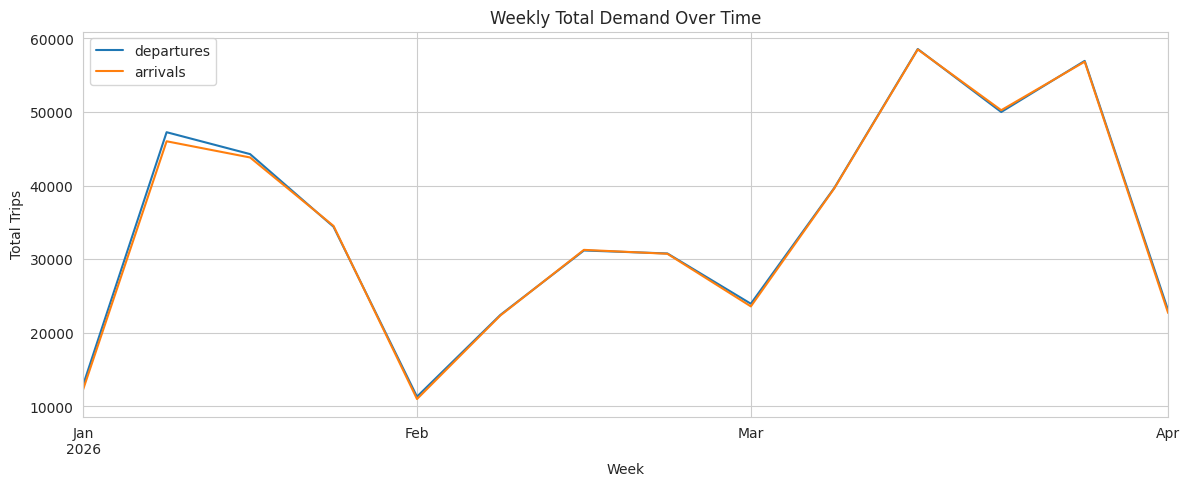

In [5]:
weekly = hourly.set_index("hour").resample("W")[["departures", "arrivals"]].sum()

fig, ax = plt.subplots(figsize=(14, 5))
weekly.plot(ax=ax)
ax.set_title("Weekly Total Demand Over Time")
ax.set_xlabel("Week")
ax.set_ylabel("Total Trips")
plt.savefig("eda_weekly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Station-Level Analysis

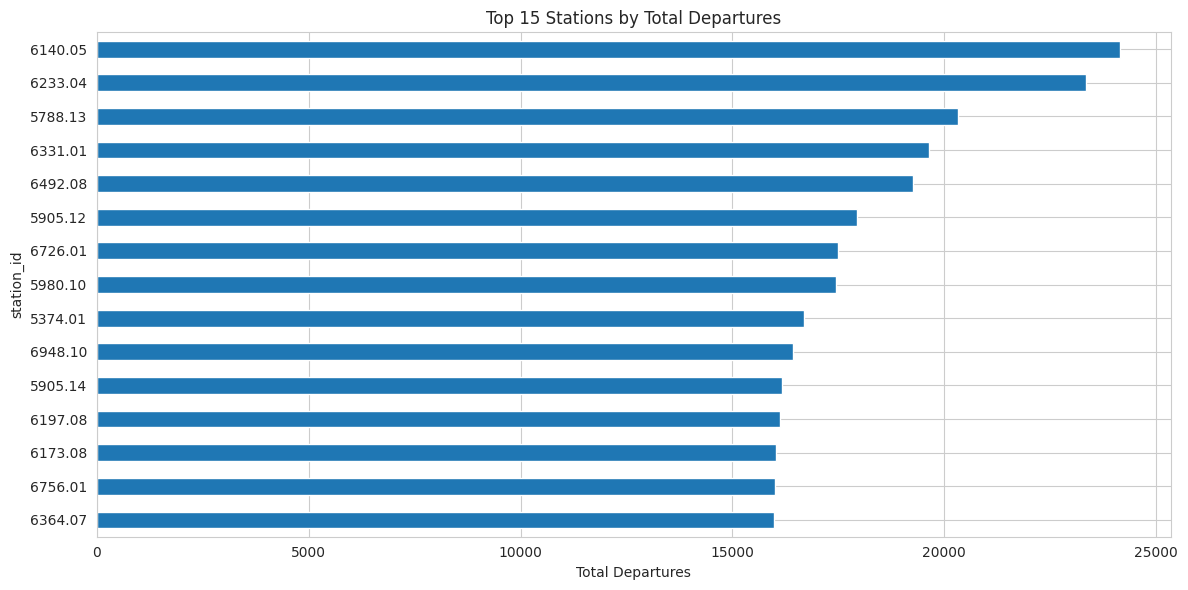

In [6]:
top_stations = hourly.groupby("station_id").agg(
    total_departures=("departures", "sum"),
    total_arrivals=("arrivals", "sum"),
    avg_hourly=("departures", "mean"),
    lat=("latitude", "first"),
    lon=("longitude", "first"),
).sort_values("total_departures", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_stations["total_departures"].head(15).plot(kind="barh", ax=ax)
ax.set_title("Top 15 Stations by Total Departures")
ax.set_xlabel("Total Departures")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("eda_top_stations.png", dpi=150, bbox_inches="tight")
plt.show()

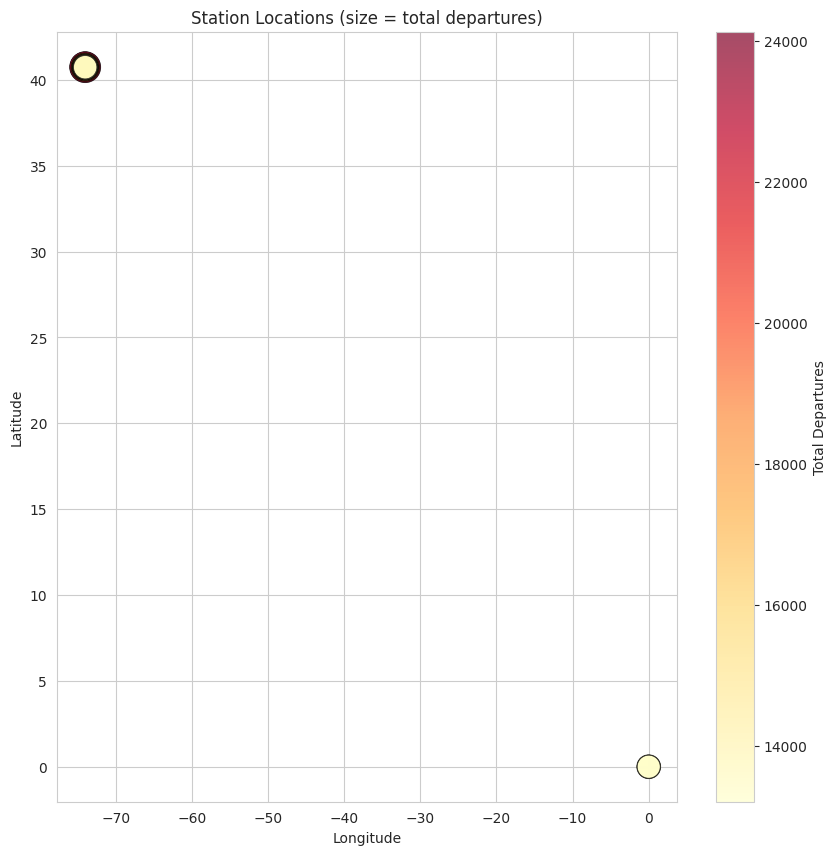

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    top_stations["lon"], top_stations["lat"],
    c=top_stations["total_departures"], cmap="YlOrRd",
    s=top_stations["total_departures"] / top_stations["total_departures"].max() * 500,
    alpha=0.7, edgecolors="black", linewidth=0.5,
)
plt.colorbar(scatter, label="Total Departures")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Station Locations (size = total departures)")
plt.savefig("eda_station_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Net Flow and Station Balance

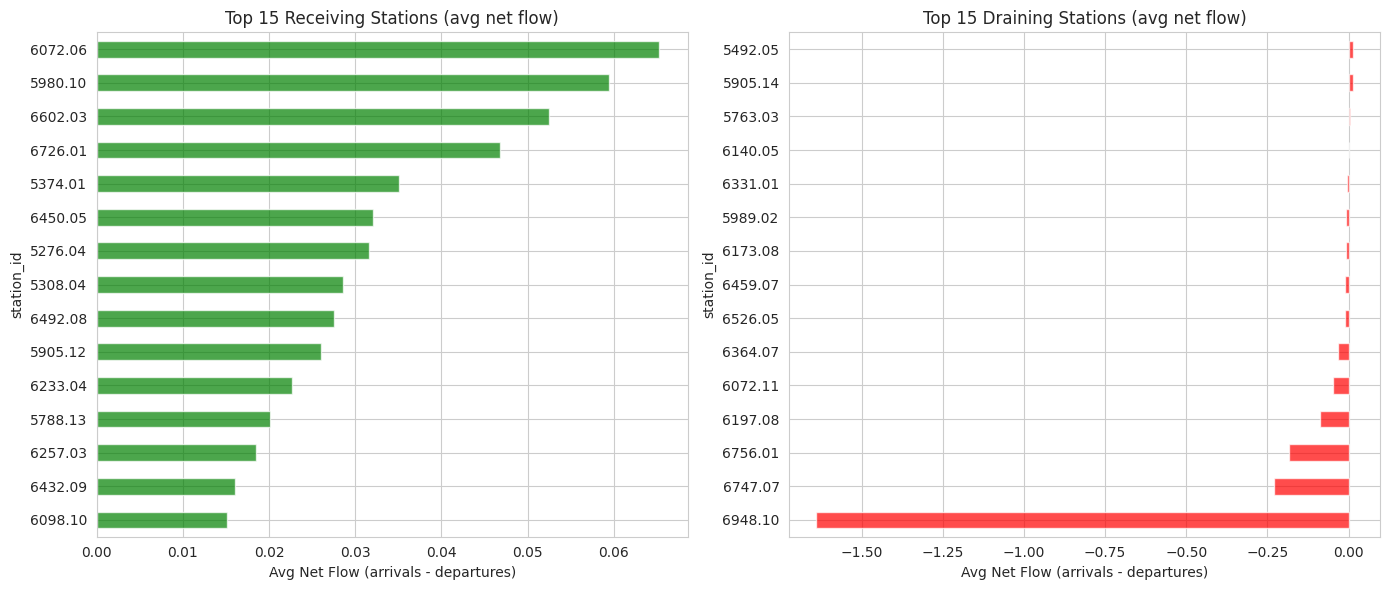

In [8]:
net_flow_by_station = hourly.groupby("station_id")["net_flow"].agg(["mean", "std"]).sort_values("mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
net_flow_by_station["mean"].tail(15).plot(kind="barh", ax=axes[0], color="green", alpha=0.7)
axes[0].set_title("Top 15 Receiving Stations (avg net flow)")
axes[0].set_xlabel("Avg Net Flow (arrivals - departures)")

net_flow_by_station["mean"].head(15).plot(kind="barh", ax=axes[1], color="red", alpha=0.7)
axes[1].set_title("Top 15 Draining Stations (avg net flow)")
axes[1].set_xlabel("Avg Net Flow (arrivals - departures)")

plt.tight_layout()
plt.savefig("eda_net_flow.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Simulated Dock Levels and Risk

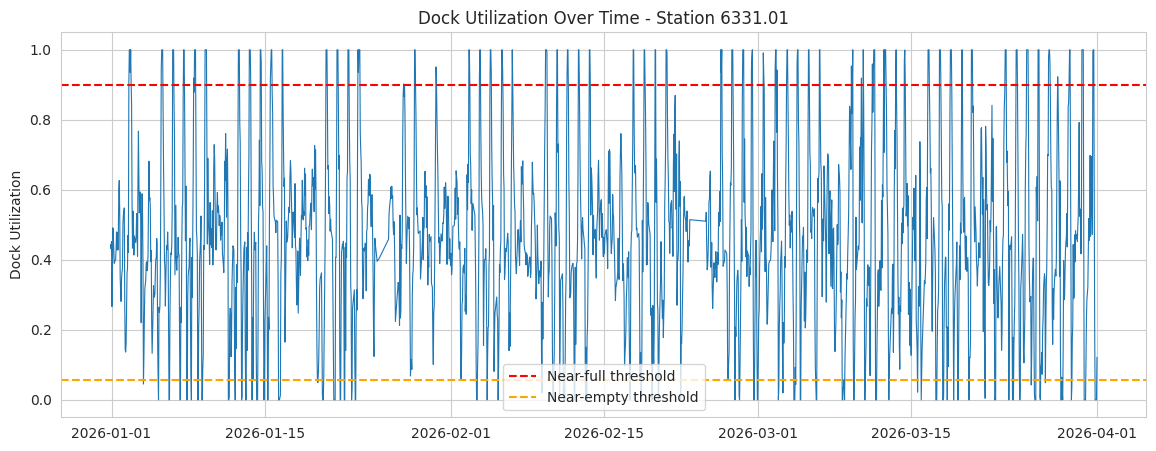

In [9]:
hourly_sim = simulate_inventory(hourly, station_info)
hourly_sim = label_risk(hourly_sim)

fig, ax = plt.subplots(figsize=(14, 5))
sample_station = hourly_sim["station_id"].value_counts().index[0]
station_data = hourly_sim[hourly_sim["station_id"] == sample_station].set_index("hour")
ax.plot(station_data.index, station_data["dock_utilization"], linewidth=0.8)
ax.axhline(0.9, color="red", linestyle="--", label="Near-full threshold")
ax.axhline(2/station_data["capacity"].iloc[0], color="orange", linestyle="--", label="Near-empty threshold")
ax.set_title(f"Dock Utilization Over Time - Station {sample_station}")
ax.set_ylabel("Dock Utilization")
ax.legend()
plt.savefig("eda_dock_utilization.png", dpi=150, bbox_inches="tight")
plt.show()

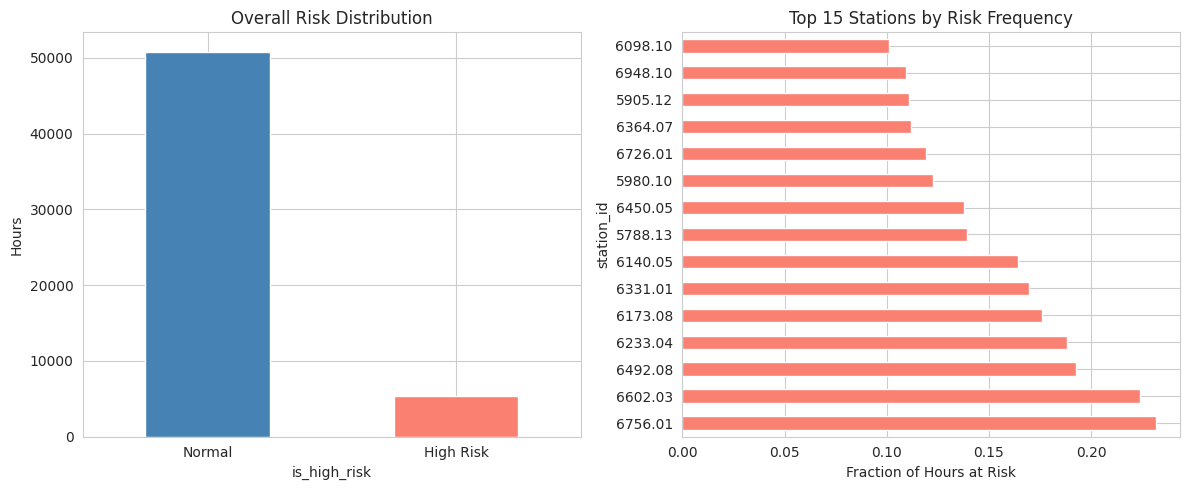

In [10]:
risk_counts = hourly_sim["is_high_risk"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
risk_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Overall Risk Distribution")
axes[0].set_xticklabels(["Normal", "High Risk"], rotation=0)
axes[0].set_ylabel("Hours")

risk_by_station = hourly_sim.groupby("station_id")["is_high_risk"].mean().sort_values(ascending=False)
risk_by_station.head(15).plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("Top 15 Stations by Risk Frequency")
axes[1].set_xlabel("Fraction of Hours at Risk")

plt.tight_layout()
plt.savefig("eda_risk_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Correlations

Adding temporal features...
Adding lag features...
Adding rolling features...


Adding trend features...
Adding cross-station features...


Adding weather features...


Adding station encoding features...


Feature matrix shape: (51128, 53)


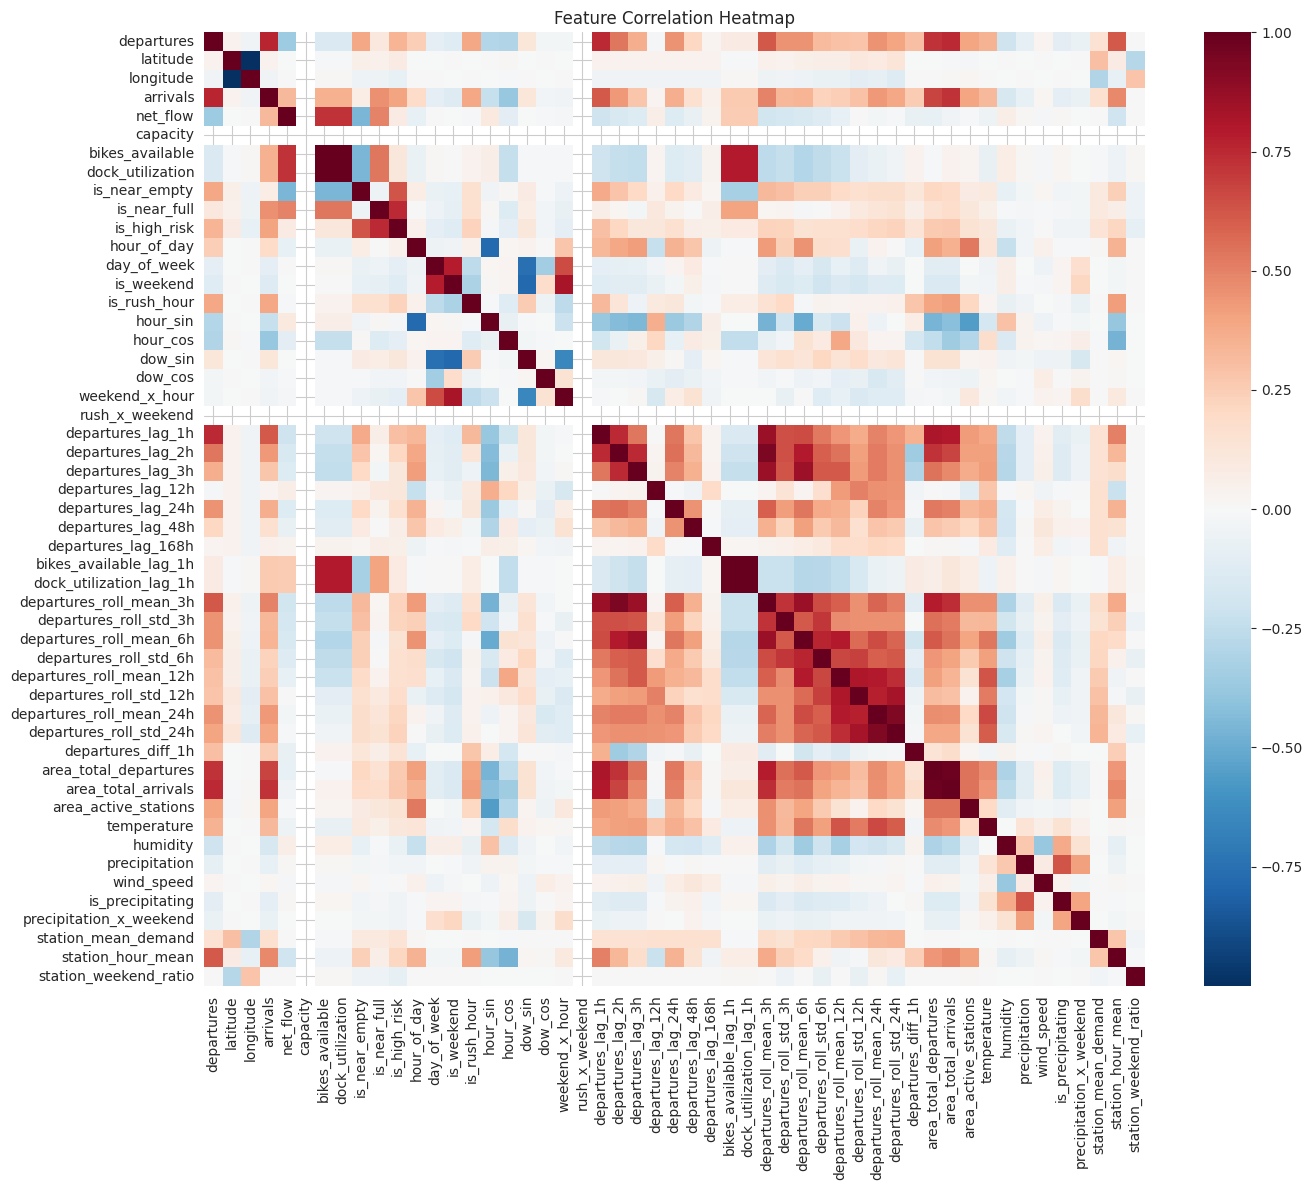

In [11]:
from features import build_features

df = build_features(hourly_sim, target="departures")
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()